In [2]:
import numpy as np 
import pandas as pd
import os

from PIL import Image
import itertools 
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix , classification_report  

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.optimizers import Adam , Adamax 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import warnings 
warnings.filterwarnings("ignore")
print("Done")

Done


In [4]:
folder_training = "/kaggle/input/brain-tumor-mri-dataset/Training"
Path = []
Labels = []

#to get the path for each Img :

folders_path = os.listdir(folder_training)
for img in folders_path : 
    FolderPath = os.path.join(folder_training, img)
    FolderName = os.listdir(FolderPath)
    for path in FolderName :
        Images_path = os.path.join(FolderPath, path)
        
        Path.append(Images_path)
        Labels.append(img)

# to creat DataFrame        
Pseries = pd.Series(Path, name = "Img_Path")
Lseries = pd.Series(Labels, name = "Img_label")
df_train = pd.concat([Pseries, Lseries], axis=1)

In [5]:
df_train

,Img_Path,Img_label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5595,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5596,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5597,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5598,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [6]:
folder_test = "/kaggle/input/brain-tumor-mri-dataset/Testing"
Path = []
Labels = []

# To get the path for each image in the test set:

folders_path = os.listdir(folder_test)  # Use folder_test here
for img in folders_path: 
    FolderPath = os.path.join(folder_test, img)  # Use folder_test here
    FolderName = os.listdir(FolderPath)
    for path in FolderName:
        Images_path = os.path.join(FolderPath, path)
        
        Path.append(Images_path)
        Labels.append(img)

# To create DataFrame        
Pseries = pd.Series(Path, name = "Img_Path")
Lseries = pd.Series(Labels, name = "Img_label")
df_test = pd.concat([Pseries, Lseries], axis=1)


In [7]:
df_test

,Img_Path,Img_label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1595,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1596,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1597,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1598,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


In [8]:
valid_df, test_df = train_test_split(df_test, train_size=0.5, shuffle= True, random_state=42)

In [9]:
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_generator = tr_gen.flow_from_dataframe(
    df_train, 
    x_col='Img_Path',  # Use the correct column name for file paths
    y_col='Img_label', # Use the correct column name for labels
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

valid_generator = ts_gen.flow_from_dataframe(
    valid_df, 
    x_col='Img_Path',  # Use the correct column name for file paths
    y_col='Img_label', # Use the correct column name for labels
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)
test_generator = ts_gen.flow_from_dataframe(
    test_df, 
    x_col='Img_Path',  # Use the correct column name for file paths
    y_col='Img_label', # Use the correct column name for labels
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=False, 
    batch_size=batch_size
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


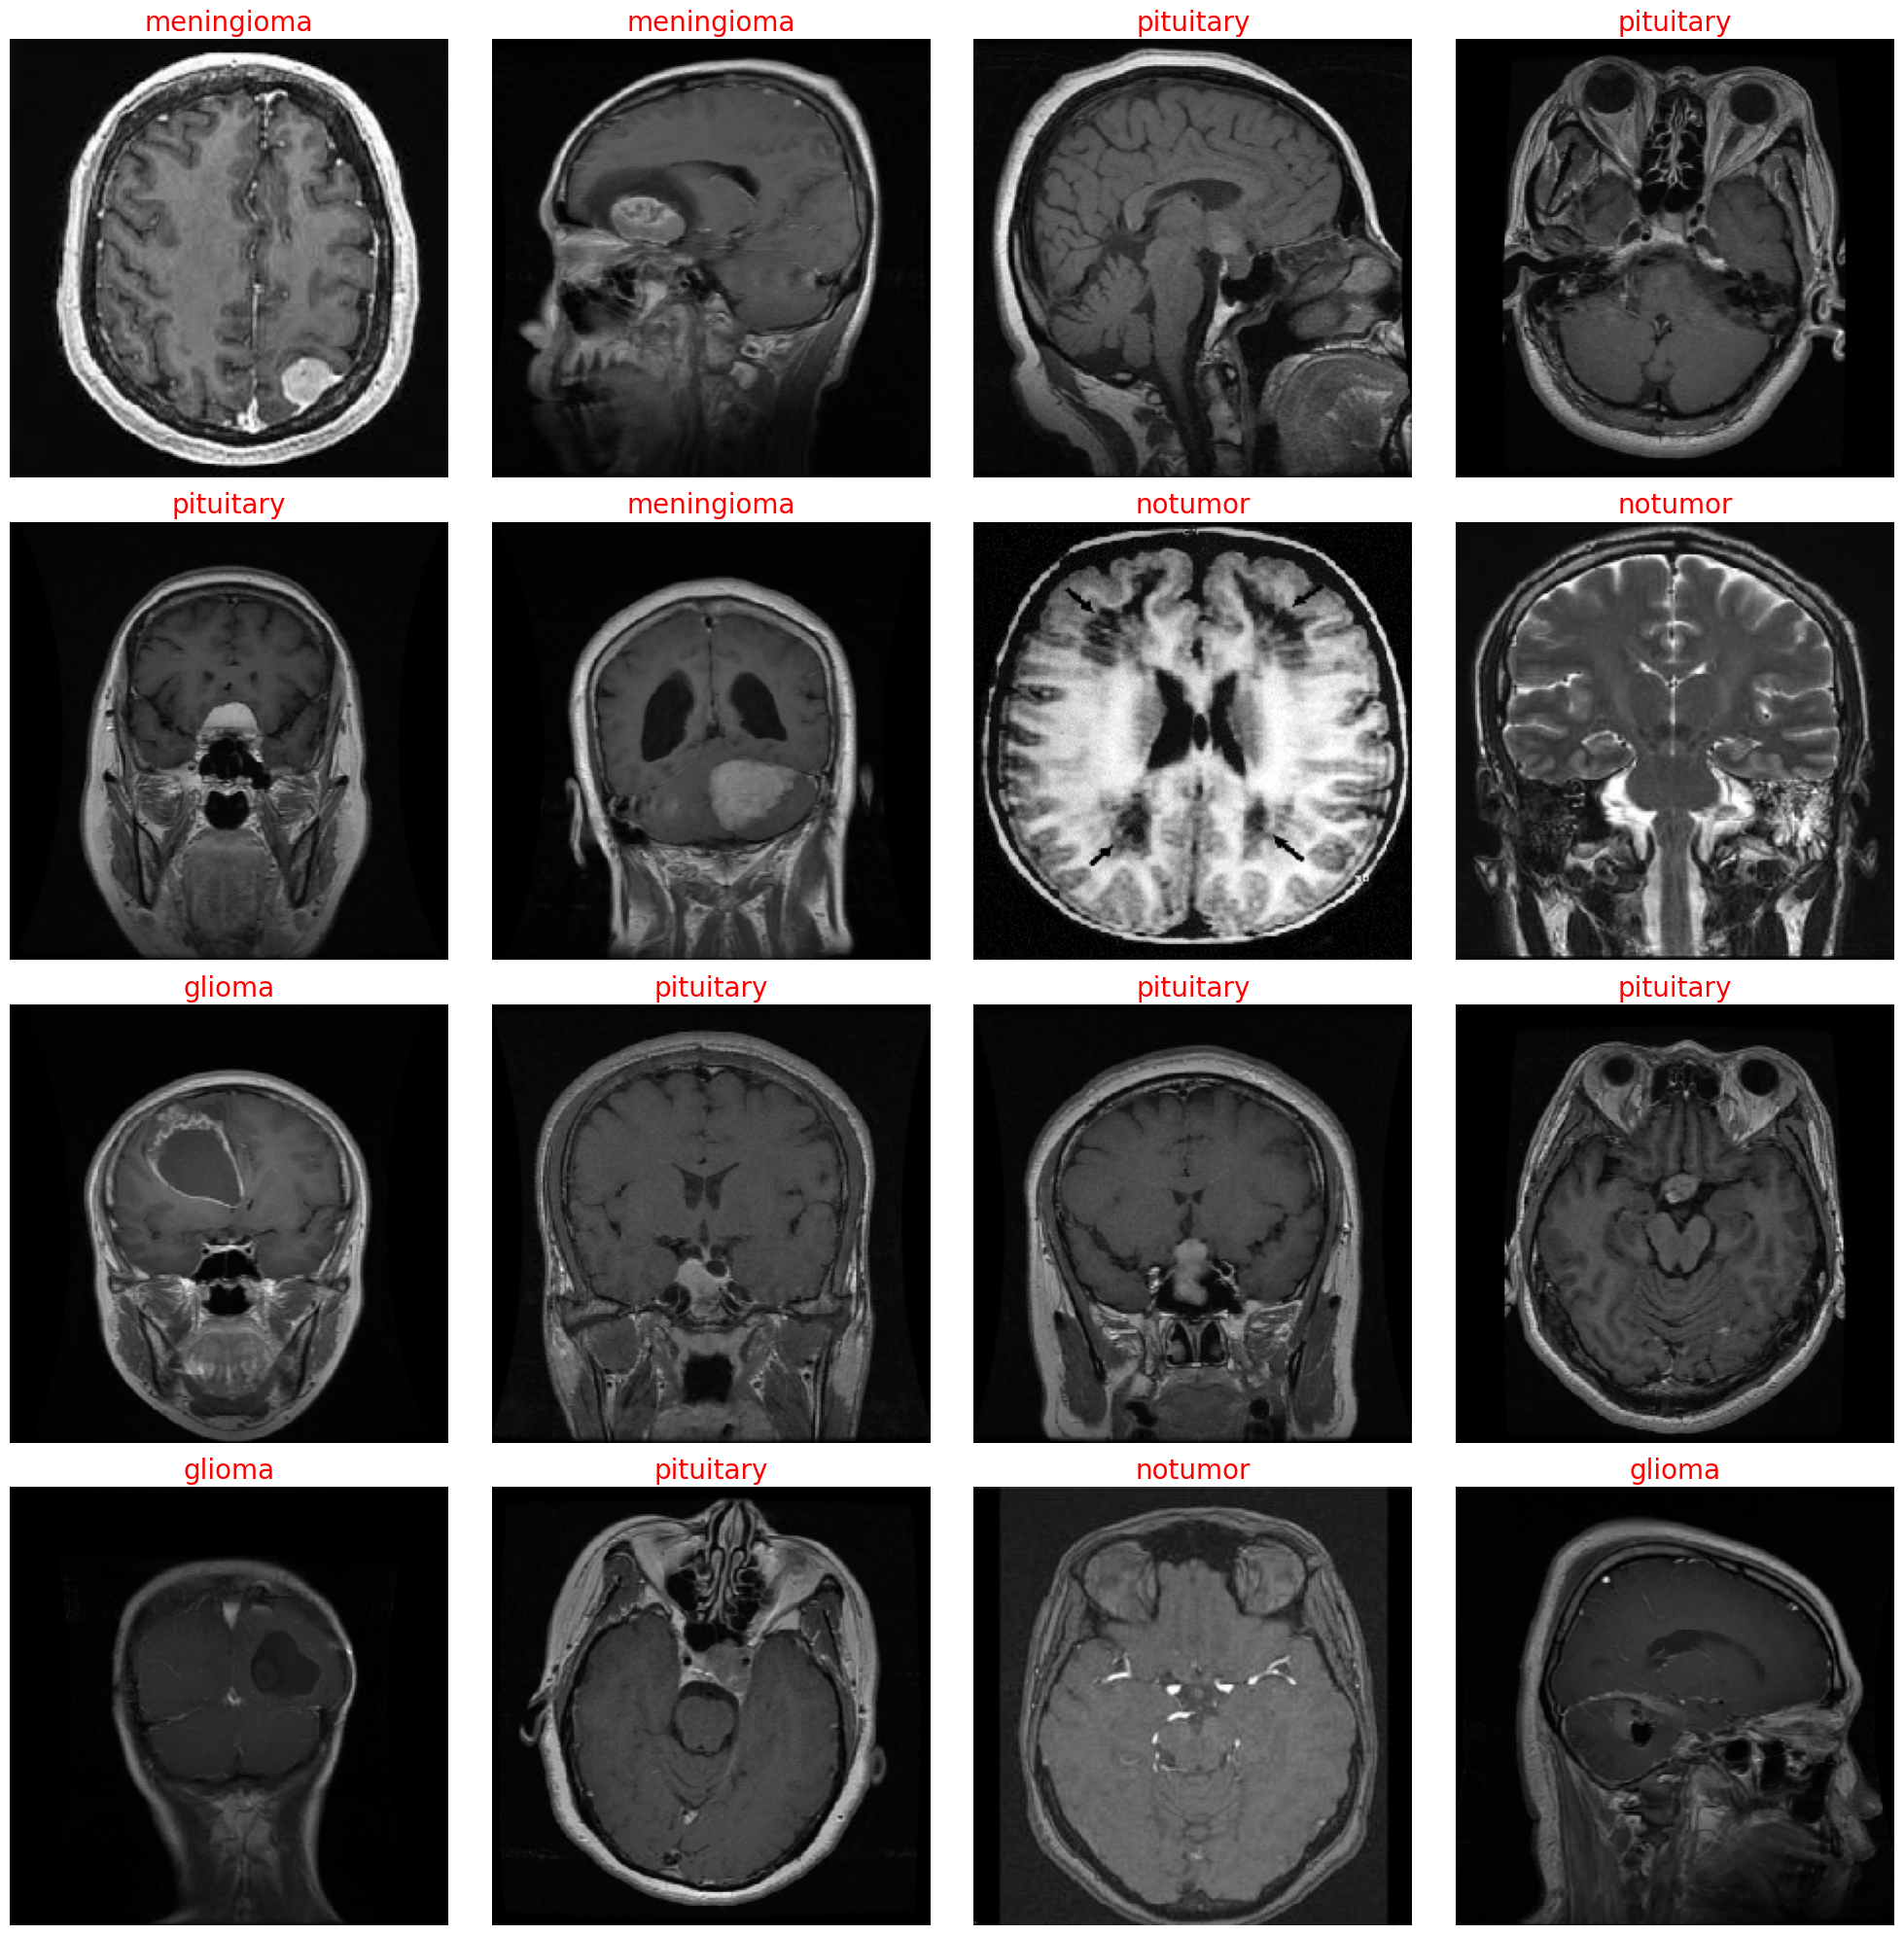

In [10]:
# Dictionary mapping class names to indices
gen_dict = train_generator.class_indices
# List of class names
classes = list(gen_dict.keys())

# Fetch a batch of images and labels
images, labels = next(train_generator)

# Set up the figure size
plt.figure(figsize=(20, 20))

# Loop through the first 20 images in the batch
for i in range(16):
    plt.subplot(4, 4, i + 1)
    
    # Normalize image pixel values to [0, 1] range
    image = images[i] / 255.0
    
    # Display the image
    plt.imshow(image)
    
    # Get the class index and class name
    index = np.argmax(labels[i])  # Get image index
    class_name = classes[index]   # Get class of image
    
    # Set the title with class name
    plt.title(class_name, color='red', fontsize=20)
    plt.axis('off')

# Adjust layout for better spacing between plots
plt.tight_layout()
# Display the plot
plt.show()

In [12]:
#models
from tensorflow import keras
from keras.applications import EfficientNetB0

In [13]:
IMG_SHAPE=(224,224,3)
base_model   = EfficientNetB0(input_shape=IMG_SHAPE,include_top=False)
print("EfficientNetB0.layers", len(base_model.layers)) #155

#Freeze the convolutional base
for layer in base_model.layers[:100]:
    layer.trainable = False

I0000 00:00:1780663321.230278     113 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0.layers 238


In [14]:
from tensorflow.keras import layers, models

def Create_model(base_model, num_classes=4):  # 4 classes
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    # Multi-class output
    predictions = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=base_model.input, outputs=predictions)
    return model

In [15]:
model_EfficientNetB0= Create_model(base_model)
model_EfficientNetB0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,365,415 (20.47 MB)

 Trainable params: 5,156,192 (19.67 MB)

 Non-trainable params: 209,223 (817.28 KB)

In [16]:
class_mode="categorical"
model_EfficientNetB0.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model_EfficientNetB0.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [21]:
epochs = 12  # number of all epochs in training

checkpointer = ModelCheckpoint(
    filepath='model.weights.best_1.h5',
    verbose=1,
    save_best_only=True
)

history = model_EfficientNetB0.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[checkpointer]
)

Epoch 1/12


I0000 00:00:1780663411.671897     177 service.cc:152] XLA service 0x7dd9d4004f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780663411.671962     177 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780663415.156045     177 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 12:43:41.877453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 12:43:42.062798: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 12:43:42.505994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8489 - loss: 0.4148
Epoch 1: val_loss improved from inf to 0.38497, saving model to model.weights.best_1.h5


350/350 ━━━━━━━━━━━━━━━━━━━━ 100s 154ms/step - accuracy: 0.8490 - loss: 0.4143 - val_accuracy: 0.9287 - val_loss: 0.3850
Epoch 2/12
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9680 - loss: 0.0884
Epoch 2: val_loss improved from 0.38497 to 0.35632, saving model to model.weights.best_1.h5


350/350 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9680 - loss: 0.0884 - val_accuracy: 0.9488 - val_loss: 0.3563
Epoch 3/12
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9877 - loss: 0.0378
Epoch 3: val_loss did not improve from 0.35632
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9877 - loss: 0.0378 - val_accuracy: 0.9438 - val_loss: 0.3915
Epoch 4/12
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9925 - loss: 0.0283
Epoch 4: val_loss did not improve from 0.35632
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9925 - loss: 0.0283 - val_accuracy: 0.9450 - val_loss: 0.3721
Epoch 5/12
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9923 - loss: 0.0194
Epoch 5: val_loss did not improve from 0.35632
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9923 - loss: 0.0194 - val_accuracy: 0.9575 - val_loss: 0.3998
Epoch 6/12
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9965 - loss: 0.0142
Epoch 6: val_loss did not improve f

350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9550 - val_loss: 0.3254
Epoch 9/12
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9985 - loss: 0.0052
Epoch 9: val_loss did not improve from 0.32537
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9450 - val_loss: 0.4293
Epoch 10/12
349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9961 - loss: 0.0138
Epoch 10: val_loss did not improve from 0.32537
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9961 - loss: 0.0138 - val_accuracy: 0.9525 - val_loss: 0.4498
Epoch 11/12
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9969 - loss: 0.0082
Epoch 11: val_loss improved from 0.32537 to 0.30837, saving model to model.weights.best_1.h5


350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9969 - loss: 0.0082 - val_accuracy: 0.9575 - val_loss: 0.3084
Epoch 12/12
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9990 - loss: 0.0042
Epoch 12: val_loss did not improve from 0.30837
350/350 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9525 - val_loss: 0.4252


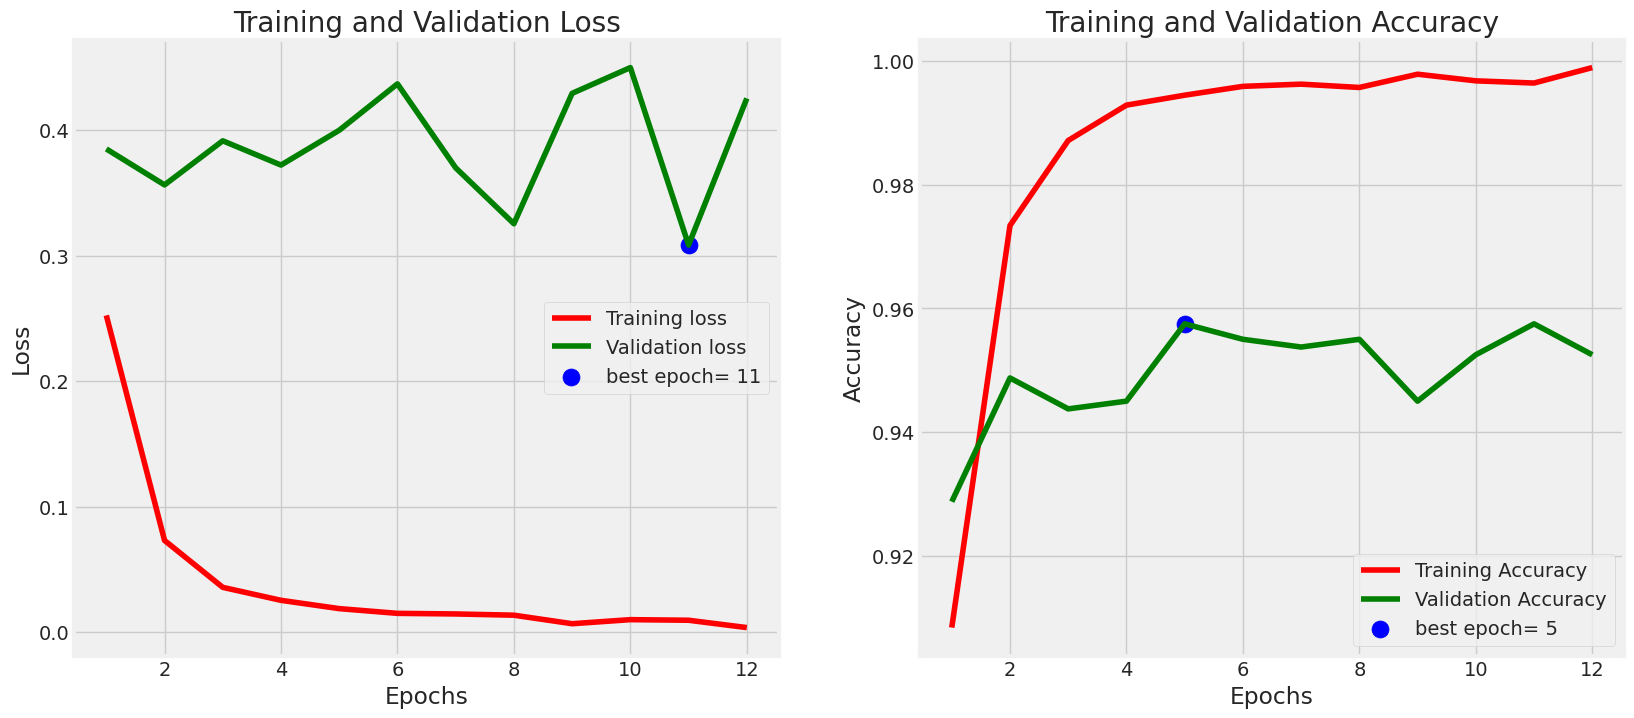

In [22]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [23]:
train_score = model_EfficientNetB0.evaluate(train_generator, verbose= 1)
valid_score =model_EfficientNetB0.evaluate(valid_generator, verbose= 1)
test_score = model_EfficientNetB0.evaluate(test_generator, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

350/350 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 1.0000 - loss: 5.5669e-05
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9549 - loss: 0.3888
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.9655 - loss: 0.3574
Train Loss:  6.436713738366961e-05
Train Accuracy:  1.0
--------------------
Validation Loss:  0.4252249002456665
Validation Accuracy:  0.9524999856948853
--------------------
Test Loss:  0.44950515031814575
Test Accuracy:  0.9524999856948853


In [24]:
preds =model_EfficientNetB0.predict(test_generator)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step


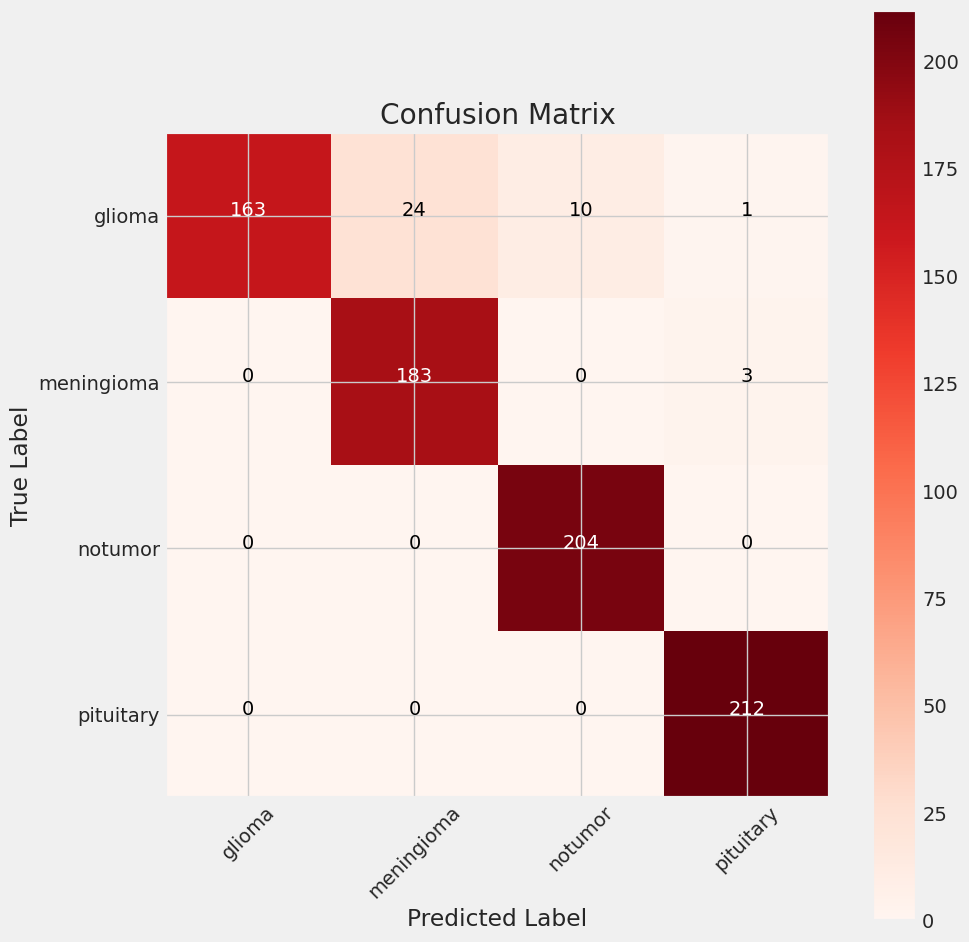

In [34]:
# Generate the class labels
g_dict = test_generator.class_indices
classes = list(g_dict.keys())

# Compute the confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap='Reds')  # Use red colormap
plt.title('Confusion Matrix')
plt.colorbar()

# Set tick marks and labels
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()  # Adjust subplots to fit into the figure area
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [35]:
print(classification_report(test_generator.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       198
  meningioma       0.88      0.98      0.93       186
     notumor       0.95      1.00      0.98       204
   pituitary       0.98      1.00      0.99       212

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.96      0.95      0.95       800



In [36]:
#Save the model

model_EfficientNetB0.save('brain_tumors_classifier.keras')

In [37]:
# Load the model
loaded_model = tf.keras.models.load_model(
    '/kaggle/working/brain_tumors_classifier.keras'
)

# Image path
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_105.jpg'
image = Image.open(image_path)

# Preprocess the image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)


# img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

img_array = tf.expand_dims(img_array, axis=0)

# Make prediction
predictions = loaded_model.predict(img_array)

# Class labels 
class_labels = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

# Predicted class
predicted_class = class_labels[np.argmax(predictions)]

print("Predicted Class:", predicted_class)
print("Prediction Probabilities:", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Predicted Class: Pituitary
Prediction Probabilities: [[4.8531582e-08 4.3386340e-08 1.5348719e-09 1.0000000e+00]]
